# STAT301 Group Project: Team 23

## What variable selection methods are most useful in creating models for Alzheimers diagnosis?

**Dataset: Alzheimers Biomarkers**

**Group Members: Kenrick Tan, Aadetri Tawara, An Trinh, Adam Walmsley**

In [1]:
library(tidyverse)
library(readr)
library(broom)
library(dplyr)
library(caret)
library(pROC)
library(glmnet)
library(rsample)
library(ggplot2)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift


Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 4.1-8



## Introduction

In this assignment analysis is conducted on the alzheimers_biomarkers_tbl_df dataset. This dataset contains info on the demographic and biological markers (biomarkers) of patients chosen for the study. The main goal is to understand what biomarkers differ between patients with Alzheimers disease and those that are healthy. 

**Attribution:** Data taken from the modeldata package version 1.4.0. Original study: Craig-Schapiro R, Kuhn M, Xiong C, et al. (2011) Multiplexed Immunoassay Panel Identifies Novel CSF Biomarkers for Alzheimer's Disease Diagnosis and Prognosis. PLoS ONE 6(4): e18850.

In this project our overarching research question is what variable selection method results in a model that is most useful for Alzheimers diagnosis? Contained within our analysis will be recommendations on when each method is the most useful. If we are interested in minimizing type 1 error, one method in particular may be favourable but for type 2 error another might be. As such, we will produce an analysis that will provide the reader with a guide on the best variable selection method to achieve the optimum in their particular metric of interest. 

## Methods and Results

Here we will perform explanatory data analysis (EDA) to summarize and explore our data, as well as narrate our plan and implementation of the steps to achieve our results. 

**Exploratory Data Analysis**

We begin EDA by downloading our data, observing its dimensions, and noticing the type of data present.

In [2]:
# Main Devleoper: Adam Walmsley

# Download the data
dataset <- read_csv("https://vincentarelbundock.github.io/Rdatasets/csv/NeuroDataSets/alzheimers_biomarkers_tbl_df.csv") |> 
    select(-rownames)

# Display a portion of the dataset
head(dataset,3)

Rows: 333 Columns: 132
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (2): Genotype, Class
dbl (130): rownames, ACE_CD143_Angiotensin_Converti, ACTH_Adrenocorticotropi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


ACE_CD143_Angiotensin_Converti,ACTH_Adrenocorticotropic_Hormon,AXL,Adiponectin,Alpha_1_Antichymotrypsin,Alpha_1_Antitrypsin,Alpha_1_Microglobulin,Alpha_2_Macroglobulin,Angiopoietin_2_ANG_2,Angiotensinogen,⋯,VEGF,Vitronectin,von_Willebrand_Factor,age,tau,p_tau,Ab_42,male,Genotype,Class
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2.003100,-1.386294,1.0983867,-5.360193,1.740466,-12.63136,-2.577022,-72.65029,1.0647107,2.510547,⋯,22.03456,-0.04082199,-3.146555,0.9876238,6.297754,4.348108,12.01968,0,E3E3,Control
1.561856,-1.386294,0.6832816,-5.020686,1.458615,-11.90988,-3.244194,-154.61228,0.7419373,2.457283,⋯,18.60184,-0.38566248,-3.863233,0.9861496,6.659294,4.859967,11.01576,0,E3E4,Control
1.520660,-1.714798,-0.1452763,-5.809143,1.193922,-13.64296,-2.882404,-136.52918,0.8329091,1.976365,⋯,17.47619,-0.22314355,-3.540459,0.9866667,6.270988,4.400247,12.30227,1,E3E4,Control


In [3]:
# Main Devleoper: Adam Walmsley

# Extract number of rows and columns
dim <- dim(dataset);
obs <- dim[1]
vars <- dim[2]
cat("Number of observations:", obs, "\n")
cat("Number of variables:", vars)

Number of observations: 333 
Number of variables: 131

In [4]:
# Main Devleoper: Adam Walmsley

# Produce a table of variables and their type
table_names_types <- data.frame(variable = names(dataset), type = sapply(dataset, class), row.names = NULL)
tail(table_names_types, 5)

,variable,type
,<chr>,<chr>
127,p_tau,numeric
128,Ab_42,numeric
129,male,numeric
130,Genotype,character
131,Class,character


From this initial look we found that there are 333 observation and 131 different variables present in the dataset. Of those variables the vast majority are numeric, but Genotype and Class are characters. The numeric variables are mostly biomarkers save a few variables like age and gender. The genotype factor highlights what variants of a specific gene a person has, and the Class factor indicates whether the person has Alzheimers disease or not.

The data collection process and assumptions are unknown but the following is assumed throughtout the ansalysis:
  1. Observations are independent
  2. The sample is representative of the population
  3. Measurements are accurate 

Now we look to clean and analyze the contents of the dataset in more detail. Firstly, we convert categorical variables to factors and scale numerical variables to be between 0 and 1.

In [5]:
# Main Devleoper: Adam Walmsley

dataset <- dataset |> 
    mutate(male = as.factor(male)) |>
    mutate(Genotype = as.factor(Genotype)) |>
    mutate(Class = as.factor(Class)) |>
    mutate(across(where(is.numeric), ~(. - min(.))/(max(.)-min(.))))

head(dataset,3)

ACE_CD143_Angiotensin_Converti,ACTH_Adrenocorticotropic_Hormon,AXL,Adiponectin,Alpha_1_Antichymotrypsin,Alpha_1_Antitrypsin,Alpha_1_Microglobulin,Alpha_2_Macroglobulin,Angiopoietin_2_ANG_2,Angiotensinogen,⋯,VEGF,Vitronectin,von_Willebrand_Factor,age,tau,p_tau,Ab_42,male,Genotype,Class
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>
0.7115432,0.5827652,0.8269560,0.4737728,0.7348825,0.5552104,0.6868486,0.9061249,0.6938191,0.6836728,⋯,0.9672411,0.7081079,0.9065813,0.6720163,0.6683462,0.5526177,0.4437537,0,E3E3,Control
0.5943364,0.5827652,0.6571324,0.5684799,0.6019504,0.6274924,0.4273344,0.5639316,0.5546734,0.6381959,⋯,0.6418462,0.5319662,0.5542880,0.4380947,0.8054334,0.7569494,0.3019029,0,E3E4,Control
0.5833935,0.3495797,0.3181611,0.3485359,0.4771109,0.4538622,0.5680623,0.6394290,0.5938908,0.2275908,⋯,0.5351433,0.6149795,0.7129520,0.5201449,0.6581975,0.5734315,0.4836832,1,E3E4,Control


Next, we observe if there is any class imbalance in the dataset.

In [6]:
# Main Devleoper: Adam Walmsley

counts_male <- dataset |> count(male)
counts_genotype <- dataset |> count(Genotype)
counts_class <- dataset |> count(Class)

counts_male
counts_genotype
counts_class

male,n
<fct>,<int>
0,204
1,129


Genotype,n
<fct>,<int>
E2E2,2
E2E3,37
E2E4,8
E3E3,167
E3E4,106
E4E4,13


Class,n
<fct>,<int>
Control,242
Impaired,91


Now we have converted all categorical variables to factors, scaled all numerical variables to the range (0,1) and looked for any class imbalance. Class imbalance is clearly prevelant in this dataset. There are 204 females to 129 males, the spread across genotypes is uneven, and there are 242 measurements of healthy people compared with 91 measurements of patients with Alzheimers. 

Now we look to explore our data using a plot to address the research question and explore the data further. Since the focus of our research question is on variable selection methods, we want to be certain that there are indeed biomarkers in our dataset that can aid in prediction, otherwise all variable selection methods will not be very useful. To do this we will first obtain the two biomarkers with the highest variance in the dataset. High variance is indicative of a large spread which could mean it is useful in differentiating between classes of diagnosis and thus be useful. After obtaining these variables we will plot...

In [7]:
# Main Devleoper: Adam Walmsley

top2_var <- dataset |>
  select(where(is.numeric), -age) |>
  summarise(across(everything(), var)) |>
  unlist() |>
  sort(decreasing = TRUE) |>
  head(2) |>
  names()

top2_var

[1] "Ab_42"              "C_Reactive_Protein"

In [8]:
# Main Devleoper: Adam Walmsley

plotting_data <- dataset |>
    select(all_of(top2_var), male, Class) |>
    pivot_longer(
        cols = all_of(top2_var),
        names_to = 'Biomarker',
        values_to = 'Value'
    )

head(plotting_data, 3)

male,Class,Biomarker,Value
<fct>,<fct>,<chr>,<dbl>
0,Control,Ab_42,0.4437537
0,Control,C_Reactive_Protein,0.7962126
0,Control,Ab_42,0.3019029


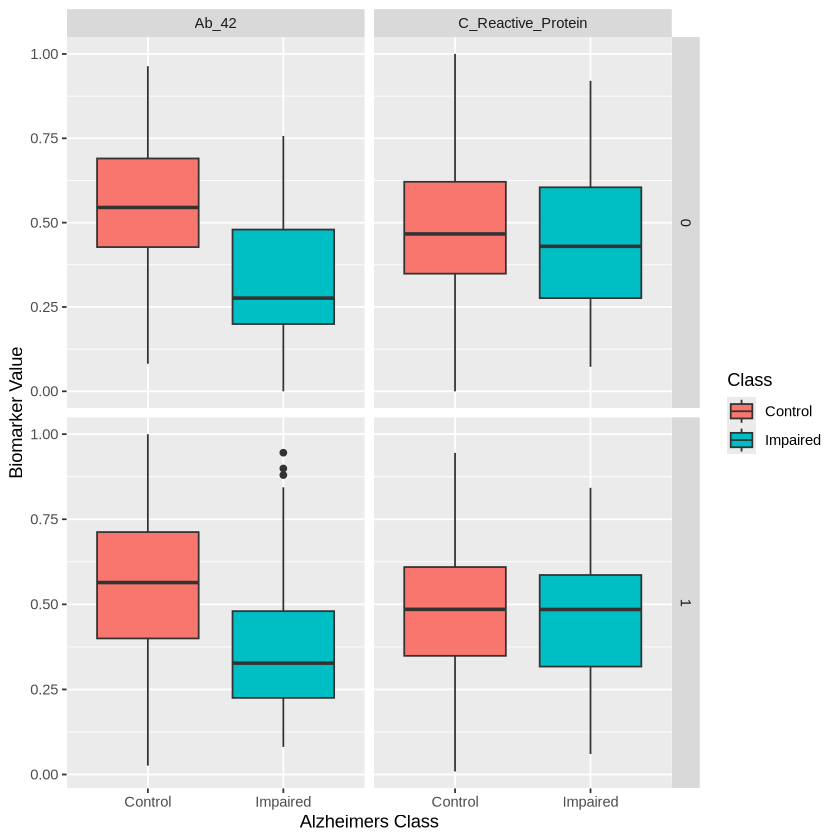

In [9]:
# Main Devleoper: Adam Walmsley

ggplot(plotting_data, aes(x = Class, y = Value, fill = Class)) +
    geom_boxplot() +
    facet_grid(male ~ Biomarker, scales = 'free_y') +
    labs(Title = 'Top 2 Biomarker by Variance', 
        x = 'Alzheimers Class',
        y = 'Biomarker Value')

From the plot above the values of the biomarker Ab_42 clearly show a difference in the Class of the patients. Gender less so. Also c_Reactive_protein seems much less promising as a useful predictor of class. This is a promising result nonetheless since we have confirmed the amounts of the values of some biomarkers likely will help us in predicting the class of patients and thus variable selection methods can be analyzed further. 

**Methods: Plan**

To conduct our analysis in hopes of answering the esearch question we will follow the steps below.
1. Split data into train and test set
2. Fit stepwise, ridge, lasso models on the training set
3. Using the chosen variables for each model, fit a logistic regression model on the training set
4. Evaluate all models on the test set
5. Compare all models on various metrics including accuracy, precision, recall, F1, AUC, RMSE, R^2, adj_R^2, model complexity (number of variables selected).


## Discussion

## References